In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [46]:
samples_order = [
    "AF_M_8", "AF_M_6", "AF_F_9", "AF_F_7", "AF_M_9",
    "AF_F_6", "AF_M_7", "AF_M_10", "AF_F_10", "AF_F_8"
]
X_CHROMS = {"OX359249.1","OX359250.1"}   # adjust to your X chromosome IDs
MIN_DP = 8
samples = pd.read_csv("samples.txt", sep=r"\s+")
samples["sex"] = samples["sex"].map({"M": "Male", "F": "Female"})
df = pd.read_csv("allele_counts.tsv", sep="\t", header=None)
df = df.rename(columns={
    0: "CHROM",
    1: "POS",
    2: "REF",
    3: "ALT"
})
records = []
for i, sample in enumerate(samples_order):
    gt_col = 4 + 2*i
    ad_col = 5 + 2*i

    tmp = df[["CHROM", "POS", "REF", "ALT"]].copy()
    tmp["sample"] = sample
    tmp["GT"] = df[gt_col]
    tmp["AD"] = df[ad_col]

    records.append(tmp)

long_df = pd.concat(records, ignore_index=True)

In [49]:
long_df['GT'].value_counts()

GT
1/1    154662
0/0     97974
0/1     81486
1|1     10094
0|0      6257
0|1      5275
.         658
2|2       154
1|0       127
1|2        86
2|1        79
0|2        58
Name: count, dtype: int64

In [50]:
long_df = long_df[long_df["GT"] == "0/1"]
long_df[["AD1", "AD2"]] = long_df["AD"].str.split(",", expand=True).astype(int)
long_df["DP"] = long_df["AD1"] + long_df["AD2"]
long_df = long_df[long_df["DP"] >= MIN_DP]
long_df["AD1_frac"] = long_df["AD1"] / long_df["DP"]
long_df["AD2_frac"] = long_df["AD2"] / long_df["DP"]
long_df

/var/folders/f7/w9mgqp1n79s37vy6cvsfp35m0000gt/T/ipykernel_45520/825449832.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  long_df[["AD1", "AD2"]] = long_df["AD"].str.split(",", expand=True).astype(int)
/var/folders/f7/w9mgqp1n79s37vy6cvsfp35m0000gt/T/ipykernel_45520/825449832.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  long_df[["AD1", "AD2"]] = long_df["AD"].str.split(",", expand=True).astype(int)
/var/folders/f7/w9mgqp1n79s37vy6cvsfp35m0000gt/T/ipykernel_45520/825449832.py:3: SettingWithCopyWa

,CHROM,POS,REF,ALT,sample,GT,AD,AD1,AD2,DP,AD1_frac,AD2_frac
46,OX359245.1,4349510,A,T,AF_M_8,0/1,"25,4",25,4,29,0.862069,0.137931
47,OX359245.1,4349528,G,T,AF_M_8,0/1,"25,4",25,4,29,0.862069,0.137931
52,OX359245.1,5265480,C,T,AF_M_8,0/1,"65,19",65,19,84,0.773810,0.226190
53,OX359245.1,5265492,A,G,AF_M_8,0/1,"66,19",66,19,85,0.776471,0.223529
54,OX359245.1,5265531,A,T,AF_M_8,0/1,"73,13",73,13,86,0.848837,0.151163
...,...,...,...,...,...,...,...,...,...,...,...,...
356857,CAMXBY010000060.1,26897,G,C,AF_F_8,0/1,"27,21",27,21,48,0.562500,0.437500
356896,CAMXBY010000076.1,2897,C,T,AF_F_8,0/1,"36,42",36,42,78,0.461538,0.538462
356897,CAMXBY010000076.1,5021,T,C,AF_F_8,0/1,"12,17",12,17,29,0.413793,0.586207
356898,CAMXBY010000076.1,5572,A,T,AF_F_8,0/1,"27,35",27,35,62,0.435484,0.564516


In [51]:
ad_df = long_df.merge(samples, on="sample", how="left")

ad_df["linkage"] = ad_df["CHROM"].apply(
    lambda c: "Xs" if c in X_CHROMS else "Autosomes"
)
ad_df = ad_df[~ad_df["CHROM"].str.startswith("CAM")]
ad_df["sex"] = pd.Categorical(
    ad_df["sex"],
    categories=["Female", "Male"],
    ordered=True
)
ad_df

,CHROM,POS,REF,ALT,sample,GT,AD,AD1,AD2,DP,AD1_frac,AD2_frac,sex,linkage
0,OX359245.1,4349510,A,T,AF_M_8,0/1,"25,4",25,4,29,0.862069,0.137931,Male,Autosomes
1,OX359245.1,4349528,G,T,AF_M_8,0/1,"25,4",25,4,29,0.862069,0.137931,Male,Autosomes
2,OX359245.1,5265480,C,T,AF_M_8,0/1,"65,19",65,19,84,0.773810,0.226190,Male,Autosomes
3,OX359245.1,5265492,A,G,AF_M_8,0/1,"66,19",66,19,85,0.776471,0.223529,Male,Autosomes
4,OX359245.1,5265531,A,T,AF_M_8,0/1,"73,13",73,13,86,0.848837,0.151163,Male,Autosomes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81001,OX359248.1,57618220,C,T,AF_F_8,0/1,"2,7",2,7,9,0.222222,0.777778,Female,Autosomes
81002,OX359248.1,57620029,C,T,AF_F_8,0/1,"4,17",4,17,21,0.190476,0.809524,Female,Autosomes
81003,OX359248.1,57621009,A,G,AF_F_8,0/1,"8,8",8,8,16,0.500000,0.500000,Female,Autosomes
81004,OX359248.1,57625373,A,G,AF_F_8,0/1,"2,13",2,13,15,0.133333,0.866667,Female,Autosomes


In [58]:
ad_df[(ad_df['sex']=='Female') & (ad_df['linkage']=='Xs')]

,CHROM,POS,REF,ALT,sample,GT,AD,AD1,AD2,DP,AD1_frac,AD2_frac,sex,linkage
21424,OX359249.1,222414,T,A,AF_F_9,0/1,"111,71",111,71,182,0.609890,0.390110,Female,Xs
21425,OX359249.1,222452,C,A,AF_F_9,0/1,"125,81",125,81,206,0.606796,0.393204,Female,Xs
21426,OX359249.1,242905,C,T,AF_F_9,0/1,"133,126",133,126,259,0.513514,0.486486,Female,Xs
21427,OX359249.1,302766,G,C,AF_F_9,0/1,"95,98",95,98,193,0.492228,0.507772,Female,Xs
21428,OX359249.1,419571,A,T,AF_F_9,0/1,"8,2",8,2,10,0.800000,0.200000,Female,Xs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72246,OX359250.1,42402971,G,A,AF_F_8,0/1,"101,96",101,96,197,0.512690,0.487310,Female,Xs
72247,OX359250.1,43376662,T,C,AF_F_8,0/1,"25,19",25,19,44,0.568182,0.431818,Female,Xs
72248,OX359250.1,46271305,G,A,AF_F_8,0/1,"47,61",47,61,108,0.435185,0.564815,Female,Xs
72249,OX359250.1,46461328,A,G,AF_F_8,0/1,"40,41",40,41,81,0.493827,0.506173,Female,Xs


In [57]:
ad_df[(ad_df['sex']=='Male') & (ad_df['linkage']=='Xs')]

,CHROM,POS,REF,ALT,sample,GT,AD,AD1,AD2,DP,AD1_frac,AD2_frac,sex,linkage
1909,OX359249.1,3909388,A,T,AF_M_8,0/1,"112,40",112,40,152,0.736842,0.263158,Male,Xs
1910,OX359249.1,3909402,C,T,AF_M_8,0/1,"107,42",107,42,149,0.718121,0.281879,Male,Xs
1911,OX359249.1,3909556,G,T,AF_M_8,0/1,"85,45",85,45,130,0.653846,0.346154,Male,Xs
1912,OX359249.1,3909590,T,A,AF_M_8,0/1,"83,53",83,53,136,0.610294,0.389706,Male,Xs
1913,OX359249.1,3909656,A,G,AF_M_8,0/1,"72,39",72,39,111,0.648649,0.351351,Male,Xs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59842,OX359250.1,42402957,G,C,AF_M_10,0/1,"214,55",214,55,269,0.795539,0.204461,Male,Xs
59843,OX359250.1,42402971,G,A,AF_M_10,0/1,"206,53",206,53,259,0.795367,0.204633,Male,Xs
59844,OX359250.1,46510777,C,T,AF_M_10,0/1,"26,13",26,13,39,0.666667,0.333333,Male,Xs
59845,OX359250.1,46510807,A,C,AF_M_10,0/1,"34,10",34,10,44,0.772727,0.227273,Male,Xs


In [90]:
plot_df = (
    ad_df
    .groupby(["CHROM", "POS", "sex", "linkage"])['AD2_frac'].mean()
    .reset_index()
)
plot_df.dropna(inplace=True)

/var/folders/f7/w9mgqp1n79s37vy6cvsfp35m0000gt/T/ipykernel_45520/1999630504.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["CHROM", "POS", "sex", "linkage"])['AD2_frac'].mean()


In [91]:
plot_df[(plot_df['sex']=='Female') & (plot_df['linkage'] == 'Xs')]

,CHROM,POS,sex,linkage,AD2_frac
391525,OX359249.1,222414,Female,Xs,0.390110
391529,OX359249.1,222452,Female,Xs,0.393204
391533,OX359249.1,242905,Female,Xs,0.486486
391537,OX359249.1,270986,Female,Xs,0.230769
391545,OX359249.1,302766,Female,Xs,0.361029
...,...,...,...,...,...
567881,OX359250.1,44741753,Female,Xs,0.555556
570733,OX359250.1,46271305,Female,Xs,0.564815
570741,OX359250.1,46461060,Female,Xs,0.916667
570745,OX359250.1,46461328,Female,Xs,0.506173


In [92]:
plot_df[(plot_df['sex']=='Male') & (plot_df['linkage'] == 'Xs')]

,CHROM,POS,sex,linkage,AD2_frac
391547,OX359249.1,302766,Male,Xs,0.560606
394431,OX359249.1,3909388,Male,Xs,0.261198
394435,OX359249.1,3909402,Male,Xs,0.285080
394439,OX359249.1,3909556,Male,Xs,0.335018
394443,OX359249.1,3909590,Male,Xs,0.352393
...,...,...,...,...,...
567719,OX359250.1,44640337,Male,Xs,0.154902
570819,OX359250.1,46510777,Male,Xs,0.243590
570823,OX359250.1,46510807,Male,Xs,0.169192
571147,OX359250.1,46668624,Male,Xs,0.222222


In [105]:
filters = (plot_df['sex']=='Male') & (plot_df['linkage'] == 'Xs')
plot_df = plot_df[~filters]

In [97]:
plot_df.groupby(['sex','linkage'])['AD2_frac'].describe()

/var/folders/f7/w9mgqp1n79s37vy6cvsfp35m0000gt/T/ipykernel_45520/2194129915.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df.groupby(['sex','linkage'])['AD2_frac'].describe()


count      mean       std       min       25%       50%  \
sex    linkage                                                                
Female Autosomes  20076.0  0.452606  0.124395  0.083333  0.383838  0.461765   
       Xs          1046.0  0.452311  0.126361  0.086957  0.391097  0.463325   
Male   Autosomes  17910.0  0.448920  0.125465  0.086957  0.381651  0.459069   
       Xs           168.0  0.290333  0.163704  0.090909  0.174906  0.262864   

                       75%       max  
sex    linkage                        
Female Autosomes  0.525641  0.916667  
       Xs         0.528252  0.916667  
Male   Autosomes  0.522596  0.916667  
       Xs         0.335009  0.912879

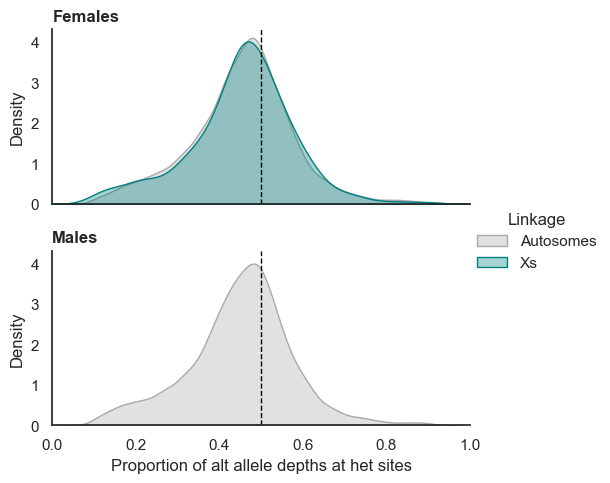

In [106]:
sns.set(style="white")

g = sns.FacetGrid(
    plot_df,#[(ad_df["AD1_frac"] > 0) & (ad_df["AD2_frac"] > 0)],
    row="sex",
    hue="linkage",
    sharex=True,
    sharey=True,
    height=2.5,
    aspect=2,
    palette={"Autosomes": "darkgray", "Xs": "teal"},
)

g.map(
    sns.kdeplot,
    "AD2_frac",
    fill=True,
    alpha=0.35,
    clip=(0, 1)
)

# Reference line
for ax in g.axes.flat:
    ax.axvline(0.5, linestyle="--", color="black", linewidth=1)

new_titles = {
    'Female': 'Females',
    'Male': 'Males',

}

g.set_titles('')
for ax, label in zip(g.axes.flat, ["Female","Male"]):
    ax.set_title(new_titles[label], loc='left', fontsize=12, weight='bold')


g.add_legend(title="Linkage")
g.set(xlim=(0, 1))
g.set_axis_labels("Proportion of alt allele depths at het sites", "Density")

#plt.savefig("AD2_frac_sex_linkage_kde.png", dpi=300, bbox_inches='tight')
#plt.savefig("AD2_frac_sex_linkage_kde.pdf", bbox_inches='tight')

plt.show()

In [54]:
import joypy

In [24]:
ad_df["group"] = (
    ad_df["sex"].astype(str)
    + " – "
    + ad_df["linkage"].astype(str)
)
ad_df["group"] = pd.Categorical(
    ad_df["group"],
    categories=[
        "Female – Xs",
        "Female – Autosomes",
        "Male – Xs",
        "Male – Autosomes"
    ],
    ordered=True
)

/Users/se13/miniforge3/envs/python/lib/python3.14/site-packages/joypy/joyplot.py:176: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby(by)


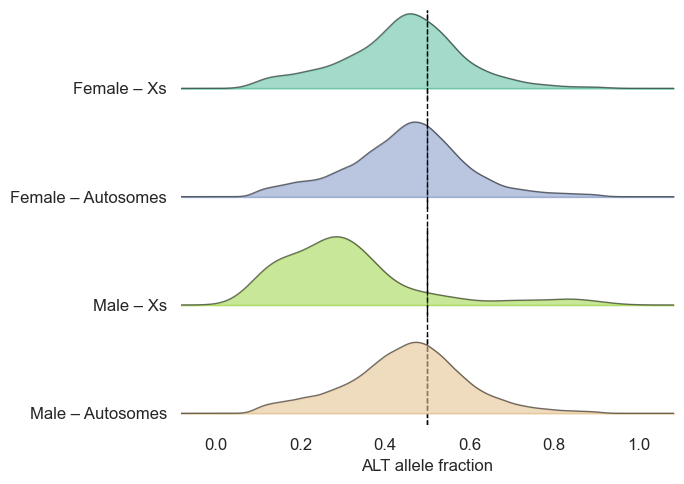

In [25]:
fig, axes = joypy.joyplot(
    ad_df,
    by="group",
    column="AD2_frac",
    overlap=0.6,
    figsize=(7, 5),
    alpha=0.6,
    linewidth=1,
    colormap=plt.cm.Set2
)

# Reference line at 0.5
for ax in axes:
    ax.axvline(0.5, linestyle="--", color="black", linewidth=1)

axes[-1].set_xlabel("ALT allele fraction")

plt.tight_layout()